# ============================================================
# INDIAN URBAN AIR QUALITY ANALYSIS
# Data Analyst Portfolio Project
# ============================================================


In [1]:
# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from collections import Counter


In [2]:
# ------------------------------------------------------------
# 2. PROJECT CONFIGURATION
# ------------------------------------------------------------

# Change this path to the location of your CSV file in VS Code
FILE_PATH = r"C:\Users\Nimesh\Desktop\Python\Indian AQI Trends and Health Risk 2019–2024\indian_aqi_health_impact_2019_2024.csv"

OUTPUT_DIR = "aqi_analysis_output"
CHART_DIR = os.path.join(OUTPUT_DIR, "charts")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)


In [3]:

# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INDIAN URBAN AIR QUALITY ANALYSIS")
print("=" * 70)

df = pd.read_csv(FILE_PATH)

print("\nDataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")



INDIAN URBAN AIR QUALITY ANALYSIS

Dataset loaded successfully.
Rows    : 10,000
Columns : 16


In [4]:
# ------------------------------------------------------------
# 4. INITIAL DATA INSPECTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())



DATASET OVERVIEW

Column Names:
['City', 'AQI', 'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Rainfall (mm)', 'Pressure (hPa)', 'Vehicle Count', 'Industrial Activity Index', 'Health Impact Score']

First 5 Records:
        City  AQI       PM2.5        PM10        NO2        CO        SO2  \
0     Rajkot   59  227.411137  160.372399  44.820603  5.985617  37.125197   
1  Bangalore  443  219.714245  279.801260  78.175010  5.061981  27.136555   
2     Bhopal   56   94.849259  262.324427  70.018054  6.589327  34.627094   
3   Srinagar  342  120.983287  213.374289  71.842615  4.443049  32.297618   
4  Hyderabad  492  184.262288  165.108731  16.167775  0.553949   6.722572   

          O3  Temperature (°C)  Humidity (%)  Wind Speed (km/h)  \
0  58.063991         11.923333     64.424980          12.921405   
1  40.777526         16.738252     23.112364          19.405409   
2  42.726937         30.388482     63.634393          13.412998  

In [5]:
# ------------------------------------------------------------
# 5. DATA QUALITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Missing values
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing_Values": missing_values,
    "Missing_Percentage": missing_percentage
})

print("\nMissing Value Report:")
print(missing_report)

missing_report.to_csv(
    os.path.join(TABLE_DIR, "missing_value_report.csv")
)

# Duplicate records
duplicate_count = df.duplicated().sum()

print(f"\nDuplicate Records: {duplicate_count}")



DATA QUALITY CHECK

Missing Value Report:
                           Missing_Values  Missing_Percentage
City                                    0                 0.0
AQI                                     0                 0.0
PM2.5                                   0                 0.0
PM10                                    0                 0.0
NO2                                     0                 0.0
CO                                      0                 0.0
SO2                                     0                 0.0
O3                                      0                 0.0
Temperature (°C)                        0                 0.0
Humidity (%)                            0                 0.0
Wind Speed (km/h)                       0                 0.0
Rainfall (mm)                           0                 0.0
Pressure (hPa)                          0                 0.0
Vehicle Count                           0                 0.0
Industrial Activity Index  

In [6]:
# ------------------------------------------------------------
# 6. CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "pct", regex=False)
    .str.replace("°", "", regex=False)
    .str.replace(".", "", regex=False)
)

print("\nCleaned Column Names:")
print(df.columns.tolist())



Cleaned Column Names:
['city', 'aqi', 'pm25', 'pm10', 'no2', 'co', 'so2', 'o3', 'temperature_c', 'humidity_pct', 'wind_speed_km/h', 'rainfall_mm', 'pressure_hpa', 'vehicle_count', 'industrial_activity_index', 'health_impact_score']


In [7]:
# ------------------------------------------------------------
# 7. CLEAN TEXT COLUMNS
# ------------------------------------------------------------

text_columns = [
    "city"
]

for column in text_columns:
    if column in df.columns:
        df[column] = (
            df[column]
            .astype(str)
            .str.strip()
        )



In [8]:
# ------------------------------------------------------------
# 8. CLEAN NUMERIC COLUMNS
# ------------------------------------------------------------

numeric_columns = [
    "aqi",
    "pm25",
    "pm10",
    "no2",
    "co",
    "so2",
    "o3",
    "temperature_c",
    "humidity_pct",
    "wind_speed_kmh",
    "rainfall_mm",
    "pressure_hpa",
    "vehicle_count",
    "industrial_activity_index",
    "health_impact_score"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


In [9]:
# ------------------------------------------------------------
# 9. VALIDATE AQI VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AQI VALIDATION")
print("=" * 70)

print("\nAQI Statistics:")
print(df["aqi"].describe())

invalid_aqi = df[
    (df["aqi"] < 0) |
    (df["aqi"] > 500)
]

print(
    f"\nInvalid AQI Records: {len(invalid_aqi):,}"
)

if len(invalid_aqi) > 0:
    invalid_aqi.to_csv(
        os.path.join(TABLE_DIR, "invalid_aqi_records.csv"),
        index=False
    )



AQI VALIDATION

AQI Statistics:
count    10000.000000
mean       273.697000
std        129.035095
min         50.000000
25%        164.000000
50%        273.000000
75%        385.000000
max        499.000000
Name: aqi, dtype: float64

Invalid AQI Records: 0


In [10]:
# ------------------------------------------------------------
# 10. CREATE AQI CATEGORIES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AQI CATEGORY ANALYSIS")
print("=" * 70)

# AQI category bands used for this portfolio analysis
aqi_bins = [
    -1,
    50,
    100,
    200,
    300,
    400,
    500
]

aqi_labels = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

df["aqi_category"] = pd.cut(
    df["aqi"],
    bins=aqi_bins,
    labels=aqi_labels
)

category_counts = (
    df["aqi_category"]
    .value_counts()
    .reindex(aqi_labels)
    .fillna(0)
    .astype(int)
)

category_report = pd.DataFrame({
    "AQI_Category": category_counts.index,
    "Observation_Count": category_counts.values
})

category_report["Percentage"] = (
    category_report["Observation_Count"] /
    len(df) * 100
).round(2)

print("\nAQI Category Distribution:")
print(category_report.to_string(index=False))

category_report.to_csv(
    os.path.join(TABLE_DIR, "aqi_category_distribution.csv"),
    index=False
)



AQI CATEGORY ANALYSIS

AQI Category Distribution:
AQI_Category  Observation_Count  Percentage
        Good                 10        0.10
Satisfactory               1134       11.34
    Moderate               2162       21.62
        Poor               2312       23.12
   Very Poor               2222       22.22
      Severe               2160       21.60


In [11]:
# ------------------------------------------------------------
# 11. BASIC DATASET PROFILE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET PROFILE")
print("=" * 70)

print(
    f"\nTotal Records       : {len(df):,}"
)

print(
    f"Unique Cities       : {df['city'].nunique():,}"
)

print(
    f"Numeric Variables   : {len(df.select_dtypes(include=np.number).columns):,}"
)

print(
    f"Average AQI         : {df['aqi'].mean():,.2f}"
)

print(
    f"Median AQI          : {df['aqi'].median():,.2f}"
)

print(
    f"Minimum AQI         : {df['aqi'].min():,.2f}"
)

print(
    f"Maximum AQI         : {df['aqi'].max():,.2f}"
)



DATASET PROFILE

Total Records       : 10,000
Unique Cities       : 24
Numeric Variables   : 15
Average AQI         : 273.70
Median AQI          : 273.00
Minimum AQI         : 50.00
Maximum AQI         : 499.00


In [12]:
# ------------------------------------------------------------
# 12. KEY KPI CALCULATIONS
# ------------------------------------------------------------

average_aqi = df["aqi"].mean()
median_aqi = df["aqi"].median()
maximum_aqi = df["aqi"].max()
minimum_aqi = df["aqi"].min()

most_common_category = (
    df["aqi_category"]
    .value_counts()
    .idxmax()
)

highest_aqi_city = (
    df.groupby("city")["aqi"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

highest_aqi_city_value = (
    df.groupby("city")["aqi"]
    .mean()
    .max()
)

lowest_aqi_city = (
    df.groupby("city")["aqi"]
    .mean()
    .sort_values()
    .index[0]
)

lowest_aqi_city_value = (
    df.groupby("city")["aqi"]
    .mean()
    .min()
)

print("\n" + "=" * 70)
print("KEY PERFORMANCE INDICATORS")
print("=" * 70)

print(
    f"\nTotal Observations     : {len(df):,}"
)

print(
    f"Average AQI            : {average_aqi:,.2f}"
)

print(
    f"Median AQI             : {median_aqi:,.2f}"
)

print(
    f"Highest AQI            : {maximum_aqi:,.2f}"
)

print(
    f"Lowest AQI             : {minimum_aqi:,.2f}"
)

print(
    f"Most Common Category   : {most_common_category}"
)

print(
    f"Highest Avg AQI City   : "
    f"{highest_aqi_city} ({highest_aqi_city_value:,.2f})"
)

print(
    f"Lowest Avg AQI City    : "
    f"{lowest_aqi_city} ({lowest_aqi_city_value:,.2f})"
)



KEY PERFORMANCE INDICATORS

Total Observations     : 10,000
Average AQI            : 273.70
Median AQI             : 273.00
Highest AQI            : 499.00
Lowest AQI             : 50.00
Most Common Category   : Poor
Highest Avg AQI City   : Ahmedabad (288.76)
Lowest Avg AQI City    : Ludhiana (263.78)


In [13]:
# ------------------------------------------------------------
# 13. CITY-LEVEL AQI ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CITY-LEVEL AQI ANALYSIS")
print("=" * 70)

city_analysis = (
    df.groupby("city")
    .agg(
        Observation_Count=("aqi", "count"),
        Average_AQI=("aqi", "mean"),
        Median_AQI=("aqi", "median"),
        Maximum_AQI=("aqi", "max"),
        Average_PM25=("pm25", "mean"),
        Average_PM10=("pm10", "mean")
    )
    .sort_values(
        "Average_AQI",
        ascending=False
    )
)

print("\nTop 10 Cities by Average AQI:")
print(
    city_analysis
    .head(10)
    .to_string()
)

city_analysis.to_csv(
    os.path.join(TABLE_DIR, "city_aqi_analysis.csv")
)



CITY-LEVEL AQI ANALYSIS

Top 10 Cities by Average AQI:
           Observation_Count  Average_AQI  Median_AQI  Maximum_AQI  Average_PM25  Average_PM10
city                                                                                          
Ahmedabad                435   288.756322       296.0          498    127.104217    168.513585
Kolkata                  417   283.695444       283.0          499    132.734420    162.241370
Thane                    433   283.443418       283.0          499    129.714309    159.834440
Jaipur                   398   281.572864       299.0          497    134.761844    160.744461
Vadodara                 417   279.760192       281.0          499    130.523344    157.242028
Lucknow                  442   277.361991       276.5          499    130.370151    163.643324
Nashik                   448   275.736607       269.0          499    131.495764    154.856531
Surat                    368   275.475543       274.5          496    133.006618    161.2

In [14]:
# ------------------------------------------------------------
# 14. TOP CITIES BY AQI
# ------------------------------------------------------------

top_10_cities = (
    city_analysis
    .head(10)
    .reset_index()
)

print("\nTop 10 Cities:")
print(top_10_cities.to_string(index=False))

top_10_cities.to_csv(
    os.path.join(TABLE_DIR, "top_10_cities_by_aqi.csv"),
    index=False
)



Top 10 Cities:
     city  Observation_Count  Average_AQI  Median_AQI  Maximum_AQI  Average_PM25  Average_PM10
Ahmedabad                435   288.756322       296.0          498    127.104217    168.513585
  Kolkata                417   283.695444       283.0          499    132.734420    162.241370
    Thane                433   283.443418       283.0          499    129.714309    159.834440
   Jaipur                398   281.572864       299.0          497    134.761844    160.744461
 Vadodara                417   279.760192       281.0          499    130.523344    157.242028
  Lucknow                442   277.361991       276.5          499    130.370151    163.643324
   Nashik                448   275.736607       269.0          499    131.495764    154.856531
    Surat                368   275.475543       274.5          496    133.006618    161.205034
Hyderabad                418   274.559809       270.0          498    126.063329    154.341467
  Chennai                419   274

In [15]:
# ------------------------------------------------------------
# 15. POLLUTANT ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("POLLUTANT ANALYSIS")
print("=" * 70)

pollutant_columns = [
    "pm25",
    "pm10",
    "no2",
    "co",
    "so2",
    "o3"
]

pollutant_summary = (
    df[pollutant_columns]
    .agg([
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
    .T
)

print("\nPollutant Summary:")
print(pollutant_summary)

pollutant_summary.to_csv(
    os.path.join(TABLE_DIR, "pollutant_summary.csv")
)



POLLUTANT ANALYSIS

Pollutant Summary:
            mean      median        min         max        std
pm25  130.406420  130.308975  10.024561  249.996746  69.034547
pm10  160.997159  161.102626  20.021018  299.977625  81.285641
no2    42.450892   42.890686   5.007963   79.986082  21.669949
co      5.045096    5.019324   0.100010    9.999906   2.860974
so2    26.190975   26.436409   2.003134   49.990917  13.870889
o3     52.486096   52.375775   5.017098   99.998487  27.209957


In [16]:
# ------------------------------------------------------------
# 16. AQI CORRELATION ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

correlation_matrix = (
    df.select_dtypes(include=np.number)
    .corr()
)

aqi_correlations = (
    correlation_matrix["aqi"]
    .drop("aqi")
    .sort_values(
        ascending=False
    )
)

print("\nCorrelation with AQI:")
print(aqi_correlations)

aqi_correlations.to_csv(
    os.path.join(TABLE_DIR, "aqi_correlations.csv")
)



CORRELATION ANALYSIS

Correlation with AQI:
co                           0.018494
temperature_c                0.010660
o3                           0.010431
industrial_activity_index    0.008662
pm25                         0.008344
rainfall_mm                  0.008155
pm10                         0.005920
wind_speed_km/h              0.004629
humidity_pct                -0.003283
no2                         -0.005108
vehicle_count               -0.007852
so2                         -0.008194
pressure_hpa                -0.010254
health_impact_score               NaN
Name: aqi, dtype: float64


In [18]:
# ------------------------------------------------------------
# 17. ENVIRONMENTAL FACTOR ANALYSIS
# ------------------------------------------------------------

environmental_columns = [
    "temperature_c",
    "humidity_pct",
    "wind_speed_kmh",
    "rainfall_mm",
    "pressure_hpa",
    "vehicle_count",
    "industrial_activity_index"
]

# Check which columns actually exist
available_columns = [
    col for col in environmental_columns
    if col in df.columns
]

missing_columns = [
    col for col in environmental_columns
    if col not in df.columns
]

print("\nAvailable environmental columns:")
print(available_columns)

print("\nMissing environmental columns:")
print(missing_columns)

# Calculate correlations only for available columns
if "aqi" in df.columns and available_columns:

    environmental_correlation = (
        df[["aqi"] + available_columns]
        .corr(numeric_only=True)["aqi"]
        .drop("aqi")
        .sort_values(ascending=False)
    )

    print("\nEnvironmental Factors Correlation with AQI:")
    print(environmental_correlation)

else:
    print("\nAQI or environmental columns are missing.")


Available environmental columns:
['temperature_c', 'humidity_pct', 'rainfall_mm', 'pressure_hpa', 'vehicle_count', 'industrial_activity_index']

Missing environmental columns:
['wind_speed_kmh']

Environmental Factors Correlation with AQI:
temperature_c                0.010660
industrial_activity_index    0.008662
rainfall_mm                  0.008155
humidity_pct                -0.003283
vehicle_count               -0.007852
pressure_hpa                -0.010254
Name: aqi, dtype: float64


In [19]:
# ------------------------------------------------------------
# 18. VEHICLE & INDUSTRIAL ACTIVITY ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VEHICLE & INDUSTRIAL ACTIVITY ANALYSIS")
print("=" * 70)

vehicle_correlation = df[
    ["vehicle_count", "aqi"]
].corr().iloc[0, 1]

industrial_correlation = df[
    ["industrial_activity_index", "aqi"]
].corr().iloc[0, 1]

print(
    f"\nVehicle Count vs AQI Correlation      : "
    f"{vehicle_correlation:.3f}"
)

print(
    f"Industrial Activity vs AQI Correlation: "
    f"{industrial_correlation:.3f}"
)



VEHICLE & INDUSTRIAL ACTIVITY ANALYSIS

Vehicle Count vs AQI Correlation      : -0.008
Industrial Activity vs AQI Correlation: 0.009


In [20]:
# ------------------------------------------------------------
# 19. HEALTH IMPACT ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HEALTH IMPACT ANALYSIS")
print("=" * 70)

print("\nHealth Impact Score Statistics:")
print(
    df["health_impact_score"]
    .describe()
)

health_unique_values = (
    df["health_impact_score"]
    .nunique()
)

print(
    f"\nUnique Health Impact Score Values: "
    f"{health_unique_values}"
)

if health_unique_values <= 1:
    print(
        "\nNOTE: Health Impact Score is constant in the supplied dataset."
    )
    print(
        "It should not be used for meaningful correlation or predictive modeling."
    )
else:
    health_correlation = df[
        ["aqi", "health_impact_score"]
    ].corr().iloc[0, 1]

    print(
        f"\nAQI vs Health Impact Correlation: "
        f"{health_correlation:.3f}"
    )



HEALTH IMPACT ANALYSIS

Health Impact Score Statistics:
count    10000.0
mean        10.0
std          0.0
min         10.0
25%         10.0
50%         10.0
75%         10.0
max         10.0
Name: health_impact_score, dtype: float64

Unique Health Impact Score Values: 1

NOTE: Health Impact Score is constant in the supplied dataset.
It should not be used for meaningful correlation or predictive modeling.


In [21]:
# ------------------------------------------------------------
# 20. AQI CATEGORY × CITY
# ------------------------------------------------------------

city_category = pd.crosstab(
    df["city"],
    df["aqi_category"]
)

print("\n" + "=" * 70)
print("CITY × AQI CATEGORY")
print("=" * 70)

print(
    city_category.head(20)
)

city_category.to_csv(
    os.path.join(
        TABLE_DIR,
        "city_aqi_category_crosstab.csv"
    )
)



CITY × AQI CATEGORY
aqi_category  Good  Satisfactory  Moderate  Poor  Very Poor  Severe
city                                                               
Agra             0            49        87   101         87      84
Ahmedabad        1            37        86   100        108     103
Bangalore        0            53        90    91         93      92
Bhopal           1            60        77    84        100      76
Chennai          0            44        91   100         94      90
Delhi            0            48        81    90         79      79
Hyderabad        0            33       106    93        103      83
Indore           1            49        75   103         79      92
Jaipur           1            42        80    78        107      90
Kolkata          0            42        93    88         97      97
Lucknow          0            44        94   107         96     101
Ludhiana         0            56       109   103         94      91
Meerut           2         

In [22]:
# ------------------------------------------------------------
# 21. HIGH AQI OBSERVATIONS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HIGH AQI OBSERVATIONS")
print("=" * 70)

high_aqi = (
    df[df["aqi"] >= 300]
    .sort_values(
        "aqi",
        ascending=False
    )
)

print(
    f"\nObservations with AQI >= 300: "
    f"{len(high_aqi):,}"
)

print(
    high_aqi[
        [
            "city",
            "aqi",
            "aqi_category",
            "pm25",
            "pm10",
            "no2",
            "co"
        ]
    ]
    .head(20)
    .to_string(index=False)
)

high_aqi.to_csv(
    os.path.join(
        TABLE_DIR,
        "high_aqi_observations.csv"
    ),
    index=False
)



HIGH AQI OBSERVATIONS

Observations with AQI >= 300: 4,403
     city  aqi aqi_category       pm25       pm10       no2       co
   Indore  499       Severe  43.927858 197.636079 29.714662 8.452098
Bangalore  499       Severe  57.931690  67.487596 46.796729 0.415772
    Thane  499       Severe 126.985246 175.310067 76.524320 6.195370
   Nashik  499       Severe 219.624671 197.679009 66.676397 9.208122
    Patna  499       Severe  20.334854 235.938013 16.100497 8.204478
   Nagpur  499       Severe  97.690014 215.493395  6.589178 6.617128
 Vadodara  499       Severe 234.754545 136.336746 18.889236 1.969787
   Nagpur  499       Severe 124.010195 114.632647 55.952579 5.990490
  Chennai  499       Severe 105.947711  38.438663 54.919963 3.464060
   Nashik  499       Severe 160.130998 230.256363 72.648737 0.639648
 Vadodara  499       Severe 223.108660 231.992917 73.466774 5.824409
  Kolkata  499       Severe 132.238404 173.143041 52.962416 9.652784
    Delhi  499       Severe 237.280446 149.

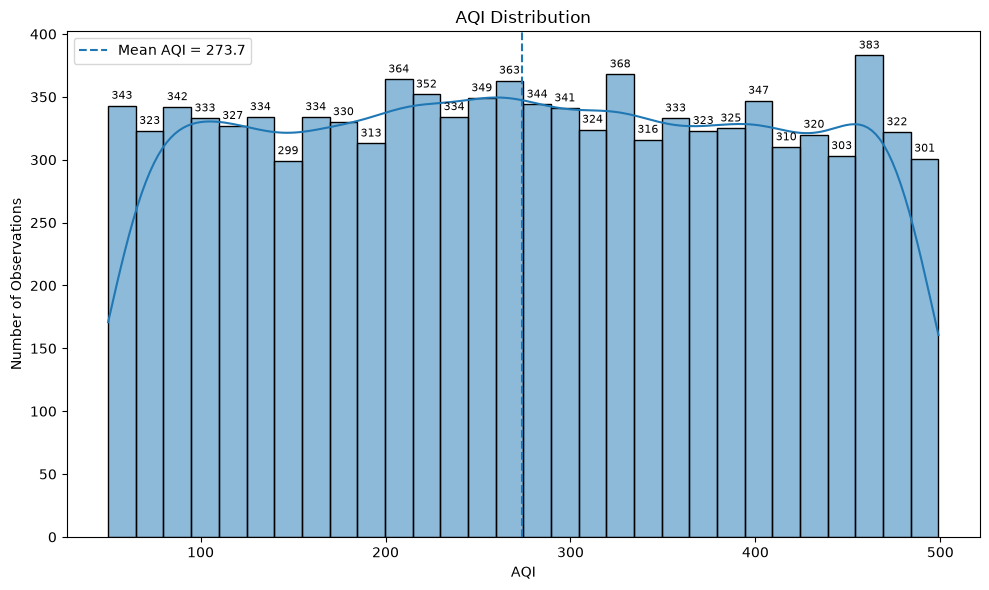

In [25]:
# ------------------------------------------------------------
# 22. AQI DISTRIBUTION VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df,
    x="aqi",
    bins=30,
    kde=True
)

plt.axvline(
    average_aqi,
    linestyle="--",
    label=f"Mean AQI = {average_aqi:.1f}"
)

# Add values on top of histogram bars
for patch in ax.patches:
    height = patch.get_height()

    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (
                patch.get_x() + patch.get_width() / 2,
                height
            ),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title(
    "AQI Distribution"
)

plt.xlabel(
    "AQI"
)

plt.ylabel(
    "Number of Observations"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "01_aqi_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


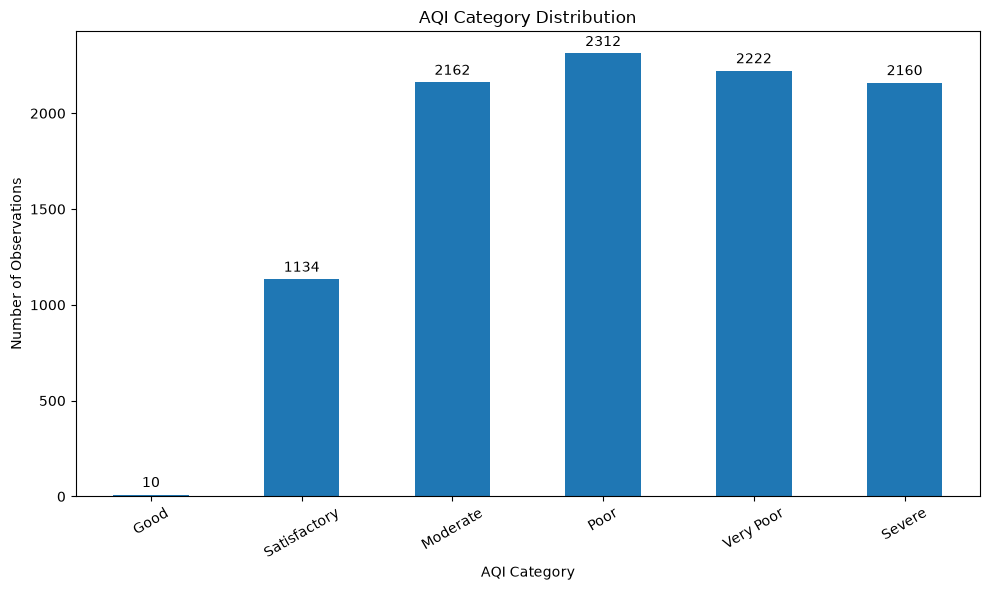

In [26]:
# ------------------------------------------------------------
# 23. AQI CATEGORY DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = category_counts.plot(
    kind="bar"
)

plt.title(
    "AQI Category Distribution"
)

plt.xlabel(
    "AQI Category"
)

plt.ylabel(
    "Number of Observations"
)

plt.xticks(
    rotation=30
)

# Add values above bars
for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "02_aqi_category_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


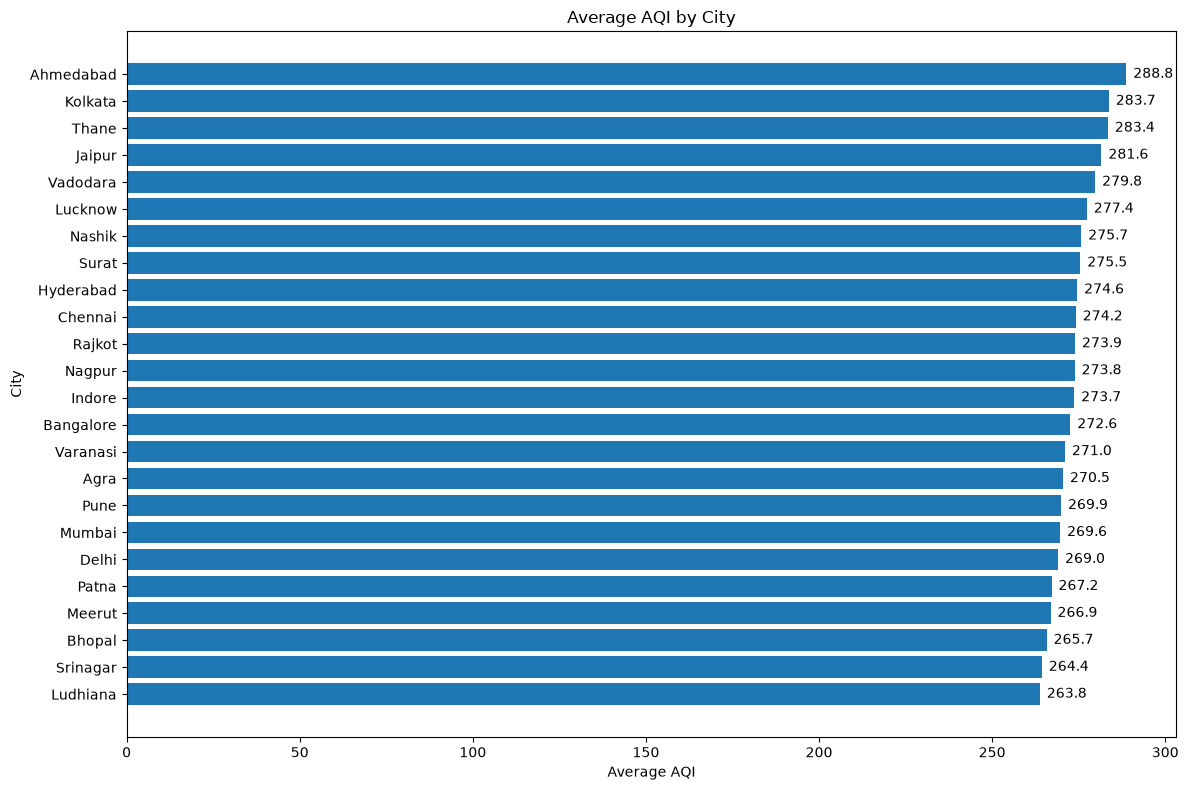

In [28]:
# ------------------------------------------------------------
# 24. AVERAGE AQI BY CITY
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

city_plot = (
    city_analysis
    .sort_values(
        "Average_AQI"
    )
)

bars = plt.barh(
    city_plot.index,
    city_plot["Average_AQI"]
)

plt.title(
    "Average AQI by City"
)

plt.xlabel(
    "Average AQI"
)

plt.ylabel(
    "City"
)

# Add values at the end of each horizontal bar
for bar in bars:

    value = bar.get_width()

    plt.annotate(
        f"{value:.1f}",
        xy=(
            value,
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(
            5,
            0
        ),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "03_average_aqi_by_city.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

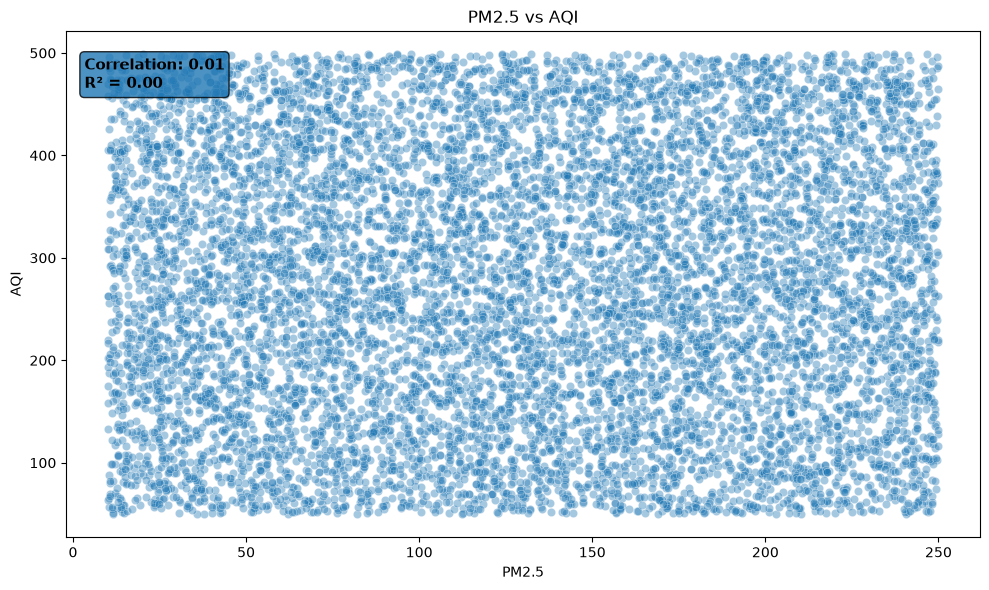

In [29]:

# ------------------------------------------------------------
# 25. PM2.5 VS AQI
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x="pm25",
    y="aqi",
    alpha=0.4
)

# Calculate correlation
pm25_corr = df["pm25"].corr(df["aqi"])

# Calculate R-squared
pm25_r2 = pm25_corr ** 2

plt.text(
    0.02,
    0.95,
    f"Correlation: {pm25_corr:.2f}\n"
    f"R² = {pm25_r2:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

plt.title(
    "PM2.5 vs AQI"
)

plt.xlabel(
    "PM2.5"
)

plt.ylabel(
    "AQI"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "04_pm25_vs_aqi.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


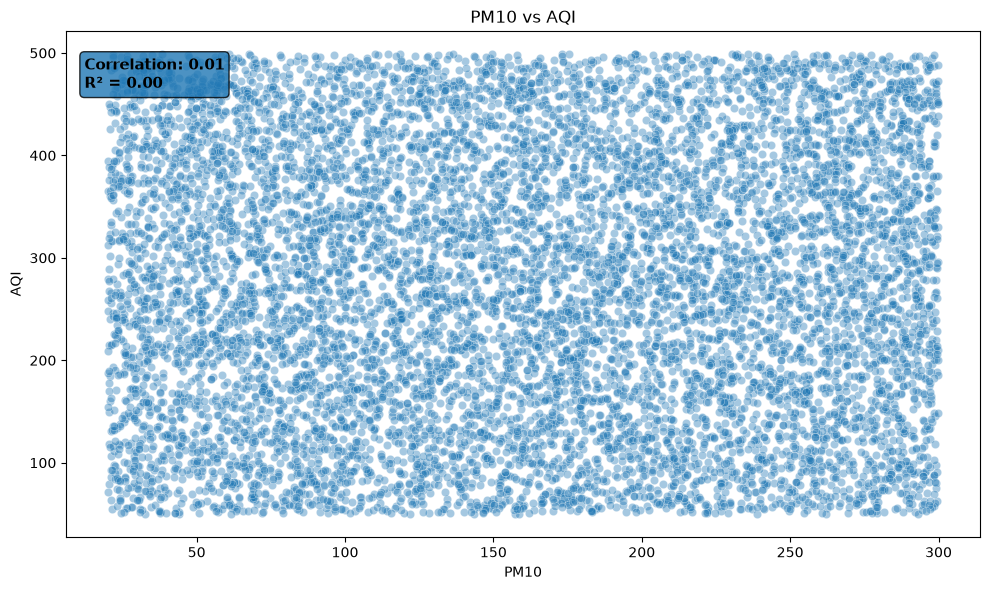

In [30]:
# ------------------------------------------------------------
# 26. PM10 VS AQI
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x="pm10",
    y="aqi",
    alpha=0.4
)

# Calculate correlation
pm10_corr = df["pm10"].corr(df["aqi"])

# Calculate R-squared
pm10_r2 = pm10_corr ** 2

plt.text(
    0.02,
    0.95,
    f"Correlation: {pm10_corr:.2f}\n"
    f"R² = {pm10_r2:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

plt.title(
    "PM10 vs AQI"
)

plt.xlabel(
    "PM10"
)

plt.ylabel(
    "AQI"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "05_pm10_vs_aqi.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


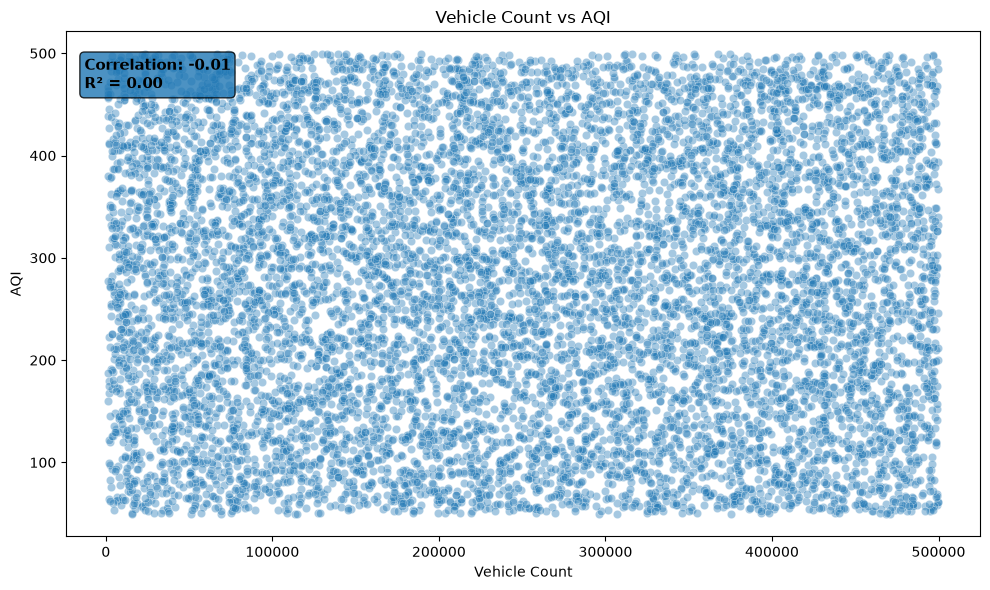

In [31]:
# ------------------------------------------------------------
# 27. VEHICLE COUNT VS AQI
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x="vehicle_count",
    y="aqi",
    alpha=0.4
)

# Calculate correlation
vehicle_corr = df["vehicle_count"].corr(df["aqi"])

# Calculate R-squared
vehicle_r2 = vehicle_corr ** 2

plt.text(
    0.02,
    0.95,
    f"Correlation: {vehicle_corr:.2f}\n"
    f"R² = {vehicle_r2:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

plt.title(
    "Vehicle Count vs AQI"
)

plt.xlabel(
    "Vehicle Count"
)

plt.ylabel(
    "AQI"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "06_vehicle_count_vs_aqi.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


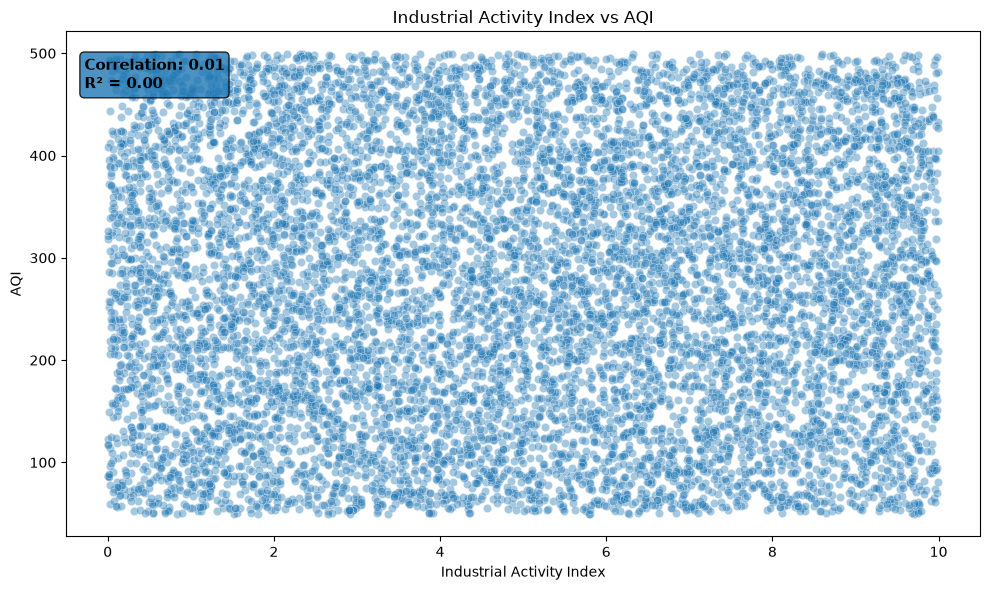

In [32]:
# ------------------------------------------------------------
# 28. INDUSTRIAL ACTIVITY VS AQI
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x="industrial_activity_index",
    y="aqi",
    alpha=0.4
)

# Calculate correlation
industrial_corr = (
    df["industrial_activity_index"]
    .corr(df["aqi"])
)

# Calculate R-squared
industrial_r2 = industrial_corr ** 2

plt.text(
    0.02,
    0.95,
    f"Correlation: {industrial_corr:.2f}\n"
    f"R² = {industrial_r2:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

plt.title(
    "Industrial Activity Index vs AQI"
)

plt.xlabel(
    "Industrial Activity Index"
)

plt.ylabel(
    "AQI"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "07_industrial_activity_vs_aqi.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


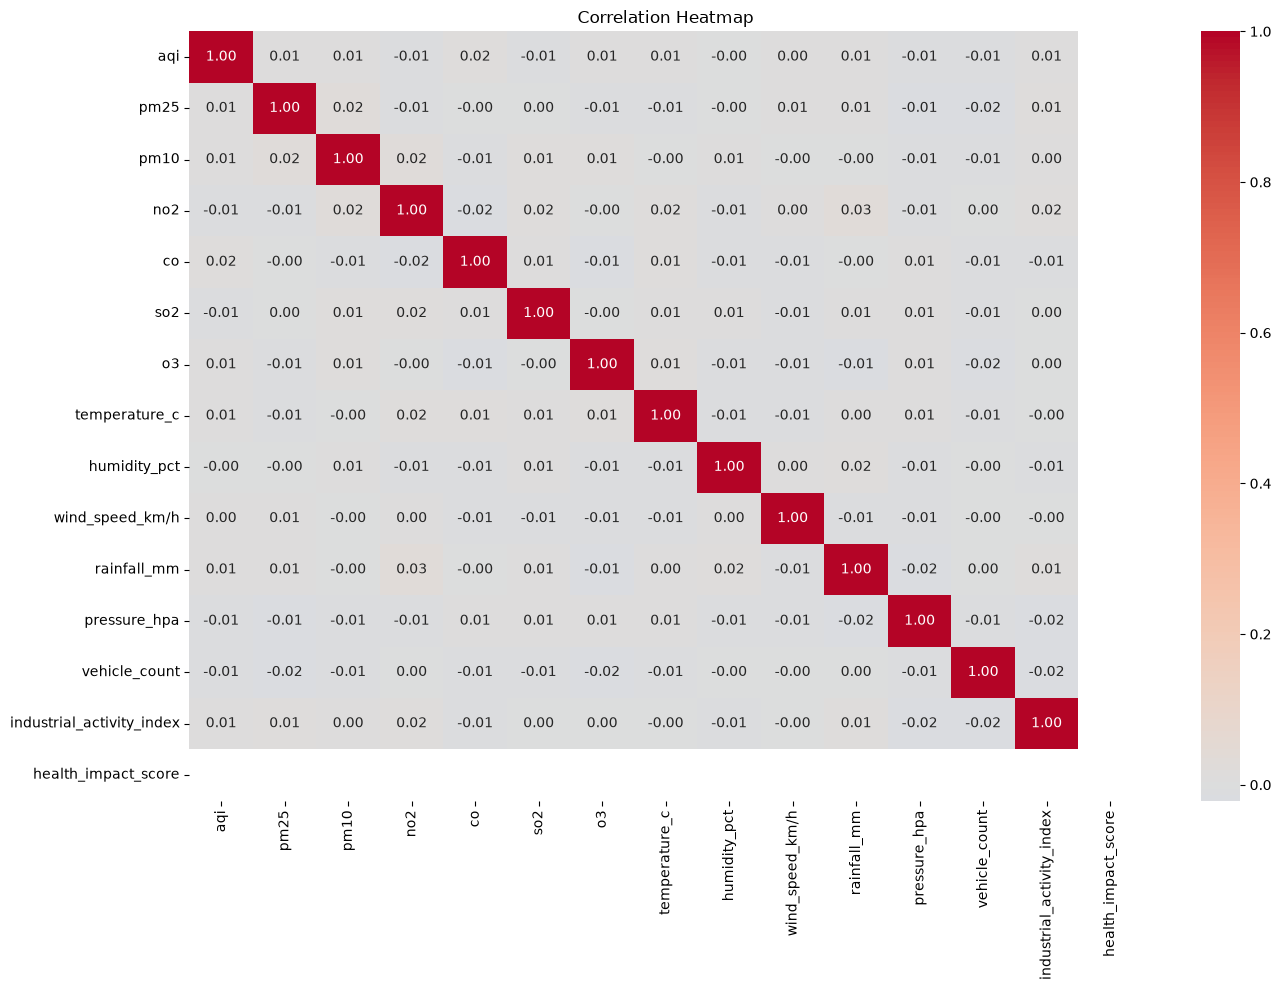

In [33]:
# ------------------------------------------------------------
# 29. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "08_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()



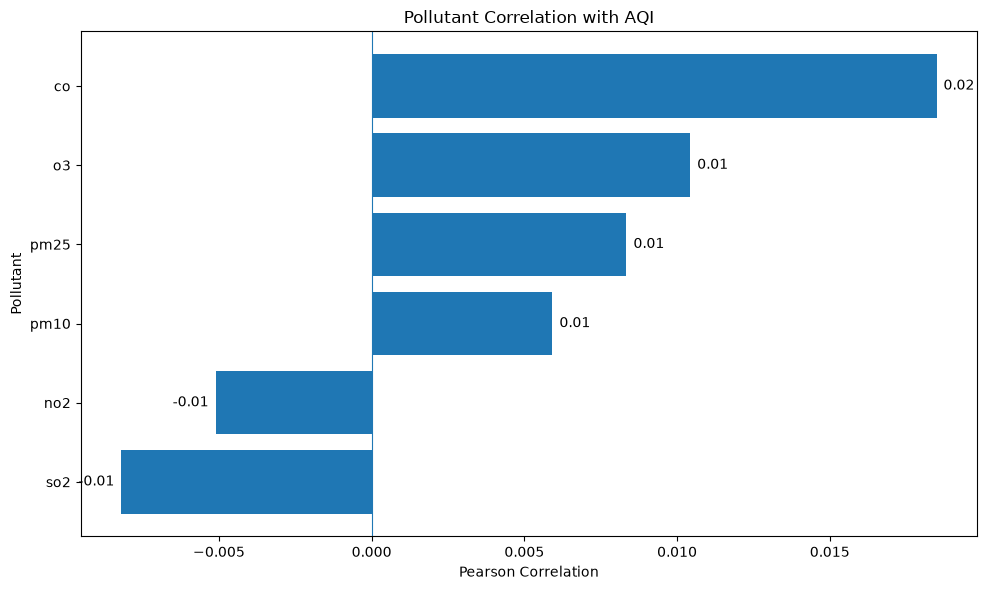

In [38]:
# ------------------------------------------------------------
# 30. TOP POLLUTANTS CORRELATED WITH AQI
# ------------------------------------------------------------

pollutant_corr = (
    correlation_matrix[
        ["aqi"]
    ]
    .drop("aqi")
)

pollutant_corr = (
    pollutant_corr
    .loc[
        [
            col for col in pollutant_columns
            if col in pollutant_corr.index
        ]
    ]
    .sort_values(
        "aqi",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    pollutant_corr.index,
    pollutant_corr["aqi"]
)

plt.axvline(
    0,
    linewidth=0.8
)

plt.title(
    "Pollutant Correlation with AQI"
)

plt.xlabel(
    "Pearson Correlation"
)

plt.ylabel(
    "Pollutant"
)

# Add correlation values to the bars
plt.bar_label(
    bars,
    fmt="%.2f",
    padding=5,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "09_pollutant_aqi_correlation.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# ------------------------------------------------------------
# 31. DATA LIMITATIONS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA LIMITATIONS")
print("=" * 70)

print(
    "\n1. The supplied dataset does not contain a date/year column."
)

print(
    "   Therefore, a genuine monthly or year-over-year AQI trend "
    "cannot be calculated from this file."
)

print(
    "\n2. The filename references a historical period, but the supplied "
    "table itself does not provide a time field."
)

print(
    "\n3. Health Impact Score has only one unique value in the supplied data."
)

print(
    "   Therefore, it cannot support meaningful health-impact correlation "
    "or predictive modeling."
)

print(
    "\n4. Correlation measures association and does not establish causation."
)

print(
    "\n5. AQI category thresholds in this project are used for analytical "
    "segmentation and should be documented with the chosen AQI methodology."
)



DATA LIMITATIONS

1. The supplied dataset does not contain a date/year column.
   Therefore, a genuine monthly or year-over-year AQI trend cannot be calculated from this file.

2. The filename references a historical period, but the supplied table itself does not provide a time field.

3. Health Impact Score has only one unique value in the supplied data.
   Therefore, it cannot support meaningful health-impact correlation or predictive modeling.

4. Correlation measures association and does not establish causation.

5. AQI category thresholds in this project are used for analytical segmentation and should be documented with the chosen AQI methodology.


In [36]:
# ------------------------------------------------------------
# 32. EXPORT CLEANED DATASET
# ------------------------------------------------------------

cleaned_file = os.path.join(
    OUTPUT_DIR,
    "cleaned_aqi_dataset.csv"
)

df.to_csv(
    cleaned_file,
    index=False
)

print(
    f"\nCleaned dataset saved to: {cleaned_file}"
)



Cleaned dataset saved to: aqi_analysis_output\cleaned_aqi_dataset.csv


In [37]:
# ------------------------------------------------------------
# 33. FINAL PROJECT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(
    f"\nTotal Records Analyzed : {len(df):,}"
)

print(
    f"Cities Analyzed        : {df['city'].nunique():,}"
)

print(
    f"Average AQI            : {average_aqi:.2f}"
)

print(
    f"Median AQI             : {median_aqi:.2f}"
)

print(
    f"Highest AQI City       : {highest_aqi_city}"
)

print(
    f"Lowest AQI City        : {lowest_aqi_city}"
)

print(
    f"Most Common AQI Class  : {most_common_category}"
)

print(
    f"\nOutput folder: {OUTPUT_DIR}"
)

print(
    "\nAnalysis completed successfully."
)

print("=" * 70)



PROJECT SUMMARY

Total Records Analyzed : 10,000
Cities Analyzed        : 24
Average AQI            : 273.70
Median AQI             : 273.00
Highest AQI City       : Ahmedabad
Lowest AQI City        : Ludhiana
Most Common AQI Class  : Poor

Output folder: aqi_analysis_output

Analysis completed successfully.
